# Experiment 9 – Recommendation Systems
**Roll Number:** 24BAD002  
**Dataset:** MovieLens 100K (ml-latest-small)


---
## Scenario 1 – User-Based Collaborative Filtering

### 1. Import Libraries

In [32]:
# Roll Number: 24BAD002
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')


### 2. Load Dataset

In [33]:
ratings = pd.read_csv('ratings.csv')
movies  = pd.read_csv('movies.csv')
tags    = pd.read_csv('tags.csv')
links   = pd.read_csv('links.csv')

print(f"ratings : {ratings.shape}")
print(f"movies  : {movies.shape}")
print(f"tags    : {tags.shape}")
print(f"links   : {links.shape}")


ratings : (100836, 4)
movies  : (9742, 3)
tags    : (3683, 4)
links   : (9742, 3)


### 3. Data Inspection & Preprocessing

In [34]:
print("=== ratings.csv ===")
display(ratings.head())

print("\n=== movies.csv ===")
display(movies.head())


=== ratings.csv ===


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931



=== movies.csv ===


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [35]:
print("=== Basic Stats ===")
display(ratings.describe())

print(f"\nUnique users  : {ratings['userId'].nunique()}")
print(f"Unique movies : {ratings['movieId'].nunique()}")
print(f"Rating range  : {ratings['rating'].min()} - {ratings['rating'].max()}")
print(f"Avg rating    : {ratings['rating'].mean():.2f}")


=== Basic Stats ===


,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09



Unique users  : 610
Unique movies : 9724
Rating range  : 0.5 - 5.0
Avg rating    : 3.50


In [36]:
print("Missing values in ratings:")
print(ratings.isnull().sum())

# convert timestamp
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')

# merge with titles
ratings_full = ratings.merge(movies[['movieId','title']], on='movieId', how='left')
display(ratings_full.head(3))


Missing values in ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


,userId,movieId,rating,timestamp,datetime,title
0,1,1,4.0,964982703,2000-07-30 18:45:03,Toy Story (1995)
1,1,3,4.0,964981247,2000-07-30 18:20:47,Grumpier Old Men (1995)
2,1,6,4.0,964982224,2000-07-30 18:37:04,Heat (1995)


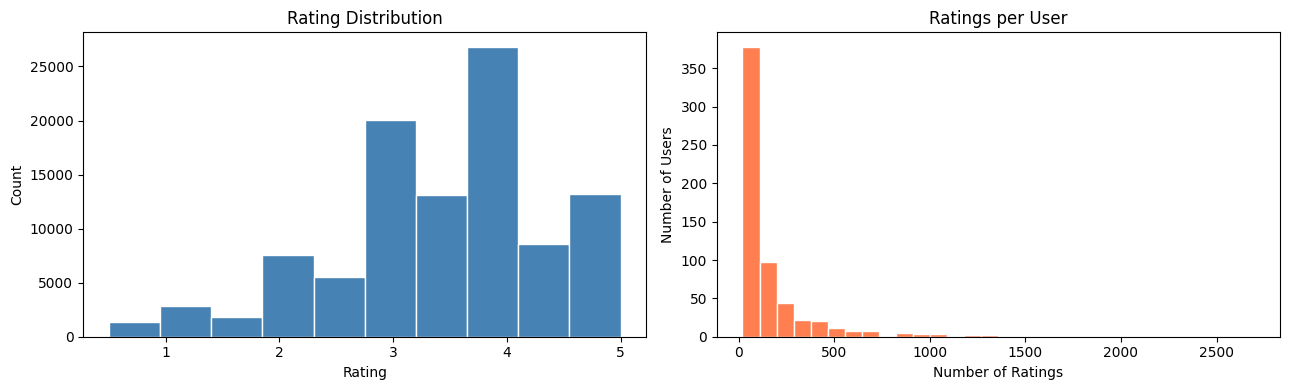

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(ratings['rating'], bins=10, color='steelblue', edgecolor='white')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

ratings_per_user = ratings.groupby('userId').size()
axes[1].hist(ratings_per_user, bins=30, color='coral', edgecolor='white')
axes[1].set_title('Ratings per User')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Users')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()


### 4. Create User-Item Matrix

In [38]:
# use top 100 active users and top 200 most-rated movies
top_users  = ratings['userId'].value_counts().head(100).index
top_movies = ratings['movieId'].value_counts().head(200).index

ratings_sub = ratings[ratings['userId'].isin(top_users) & ratings['movieId'].isin(top_movies)]

user_item_matrix = ratings_sub.pivot_table(index='userId', columns='movieId', values='rating')

print(f"User-Item Matrix shape : {user_item_matrix.shape}")
print(f"Total cells            : {user_item_matrix.shape[0] * user_item_matrix.shape[1]:,}")
print(f"Filled cells           : {user_item_matrix.count().sum():,}")


User-Item Matrix shape : (100, 200)
Total cells            : 20,000
Filled cells           : 10,806


### 5. Handle Missing Values

In [39]:
total_cells = user_item_matrix.shape[0] * user_item_matrix.shape[1]
filled      = user_item_matrix.count().sum()
sparsity    = 1 - (filled / total_cells)

print(f"Sparsity : {sparsity:.2%} of entries are missing")

# fill NaN with 0
user_item_filled = user_item_matrix.fillna(0)
print("Filled NaN with 0")
print(user_item_filled.shape)


Sparsity : 45.97% of entries are missing
Filled NaN with 0
(100, 200)


### 6. Compute User-User Cosine Similarity

In [40]:
user_sim_array = cosine_similarity(user_item_filled)
user_sim_df    = pd.DataFrame(user_sim_array,
                              index=user_item_filled.index,
                              columns=user_item_filled.index)

print(f"User similarity matrix shape : {user_sim_df.shape}")
display(user_sim_df.iloc[:5, :5].round(3))


User similarity matrix shape : (100, 100)


userId,6,18,19,21,28
userId,,,,,
6,1.000,0.360,0.405,0.225,0.316
18,0.360,1.000,0.493,0.619,0.717
19,0.405,0.493,1.000,0.494,0.454
21,0.225,0.619,0.494,1.000,0.517
28,0.316,0.717,0.454,0.517,1.000


### 7. Identify Top-N Similar Users

In [41]:
def get_similar_users(user_id, sim_df, n=10):
    if user_id not in sim_df.index:
        return pd.Series(dtype=float)
    scores = sim_df[user_id].drop(index=user_id).sort_values(ascending=False)
    return scores.head(n)

SAMPLE_USER = user_item_filled.index[0]
top_similar  = get_similar_users(SAMPLE_USER, user_sim_df, n=10)

result = pd.DataFrame({'User ID': top_similar.index, 'Cosine Similarity': top_similar.values.round(4)})
print(f"Top-10 similar users for User {SAMPLE_USER}:")
display(result)


Top-10 similar users for User 6:


,User ID,Cosine Similarity
0,140,0.5373
1,84,0.4956
2,480,0.4680
3,68,0.4659
4,91,0.4653
5,425,0.4628
6,438,0.4526
7,599,0.4434
8,57,0.4410
9,414,0.4410


### 8. Predict Ratings for Unseen Movies

In [42]:
def predict_rating_ub(target_user, movie_id, user_item_mat, sim_df, n=10):
    if movie_id not in user_item_mat.columns:
        return np.nan
    neighbors = get_similar_users(target_user, sim_df, n=n)
    numer, denom = 0.0, 0.0
    for uid, sim in neighbors.items():
        r = user_item_mat.loc[uid, movie_id]
        if r > 0:
            numer += sim * r
            denom += abs(sim)
    return numer / denom if denom > 0 else np.nan

# test on one movie
test_movie = user_item_filled.columns[5]
pred   = predict_rating_ub(SAMPLE_USER, test_movie, user_item_filled, user_sim_df)
actual = user_item_matrix.loc[SAMPLE_USER, test_movie]

print(f"User     : {SAMPLE_USER}")
print(f"Movie ID : {test_movie}")
print(f"Predicted: {pred:.2f}" if not np.isnan(pred) else "Predicted: N/A")
print(f"Actual   : {actual}"   if not np.isnan(actual) else "Actual   : not rated")


User     : 6
Movie ID : 19
Predicted: 2.19
Actual   : 2.0


### 9. Generate Top-N Recommendations

In [43]:
def recommend_user_based(target_user, user_item_mat, sim_df, movies_df, n=10):
    if target_user not in user_item_mat.index:
        return pd.DataFrame()
    user_row       = user_item_mat.loc[target_user]
    unrated_movies = user_row[user_row == 0].index.tolist()
    preds = {}
    for mid in unrated_movies:
        p = predict_rating_ub(target_user, mid, user_item_mat, sim_df)
        if not np.isnan(p):
            preds[mid] = p
    rec = pd.Series(preds).sort_values(ascending=False).head(n).reset_index()
    rec.columns = ['movieId', 'Predicted Rating']
    rec = rec.merge(movies_df[['movieId','title','genres']], on='movieId', how='left')
    return rec

recs_s1 = recommend_user_based(SAMPLE_USER, user_item_filled, user_sim_df, movies)
print(f"Top-10 recommendations for User {SAMPLE_USER} (User-Based CF):")
display(recs_s1[['title','genres','Predicted Rating']])


Top-10 recommendations for User 6 (User-Based CF):


,title,genres,Predicted Rating
0,"Matrix, The (1999)",Action|Sci-Fi|Thriller,4.649424
1,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,4.589265
2,"Princess Bride, The (1987)",Action|Adventure|Comedy|Fantasy|Romance,4.566894
3,"Godfather, The (1972)",Crime|Drama,4.502630
4,Raiders of the Lost Ark (Indiana Jones and the...,Action|Adventure,4.487994
5,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,4.481019
6,Monty Python and the Holy Grail (1975),Adventure|Comedy|Fantasy,4.427014
7,American Beauty (1999),Drama|Romance,4.407588
8,Harry Potter and the Prisoner of Azkaban (2004),Adventure|Fantasy|IMAX,4.400686
9,Saving Private Ryan (1998),Action|Drama|War,4.398414


### 10. Evaluate – RMSE and MAE

In [44]:
train_data, test_data = train_test_split(ratings_sub, test_size=0.2, random_state=42)

# build train-only matrix and similarity
train_ub_mat = train_data.pivot_table(index='userId', columns='movieId', values='rating').fillna(0)
train_ub_sim = cosine_similarity(train_ub_mat)
train_ub_sim_df = pd.DataFrame(train_ub_sim, index=train_ub_mat.index, columns=train_ub_mat.index)

print(f"Train : {len(train_data)} | Test : {len(test_data)}")

y_true_ub, y_pred_ub = [], []

for _, row in test_data.iterrows():
    uid, mid = row['userId'], row['movieId']
    if uid not in train_ub_mat.index or mid not in train_ub_mat.columns:
        continue
    p = predict_rating_ub(uid, mid, train_ub_mat, train_ub_sim_df)
    if not np.isnan(p):
        y_true_ub.append(row['rating'])
        y_pred_ub.append(p)

rmse_s1 = np.sqrt(mean_squared_error(y_true_ub, y_pred_ub))
mae_s1  = mean_absolute_error(y_true_ub, y_pred_ub)

print(f"Predictions : {len(y_pred_ub)}")
print(f"RMSE        : {rmse_s1:.4f}")
print(f"MAE         : {mae_s1:.4f}")


Train : 8644 | Test : 2162
Predictions : 2162
RMSE        : 0.9061
MAE         : 0.6975


### Visualizations – Scenario 1

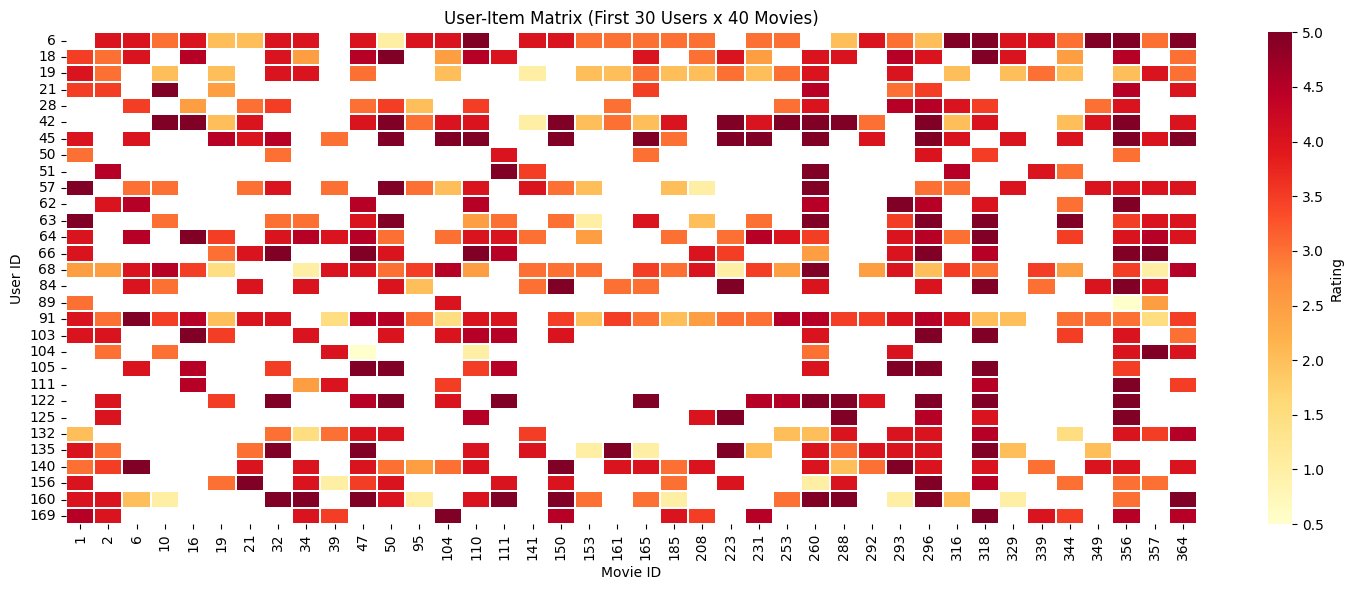

In [45]:
# Heatmap of User-Item Matrix
fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(user_item_matrix.iloc[:30, :40],
            cmap='YlOrRd', linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Rating'}, ax=ax)
ax.set_title('User-Item Matrix (First 30 Users x 40 Movies)')
ax.set_xlabel('Movie ID')
ax.set_ylabel('User ID')
plt.tight_layout()
plt.savefig('s1_user_item_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


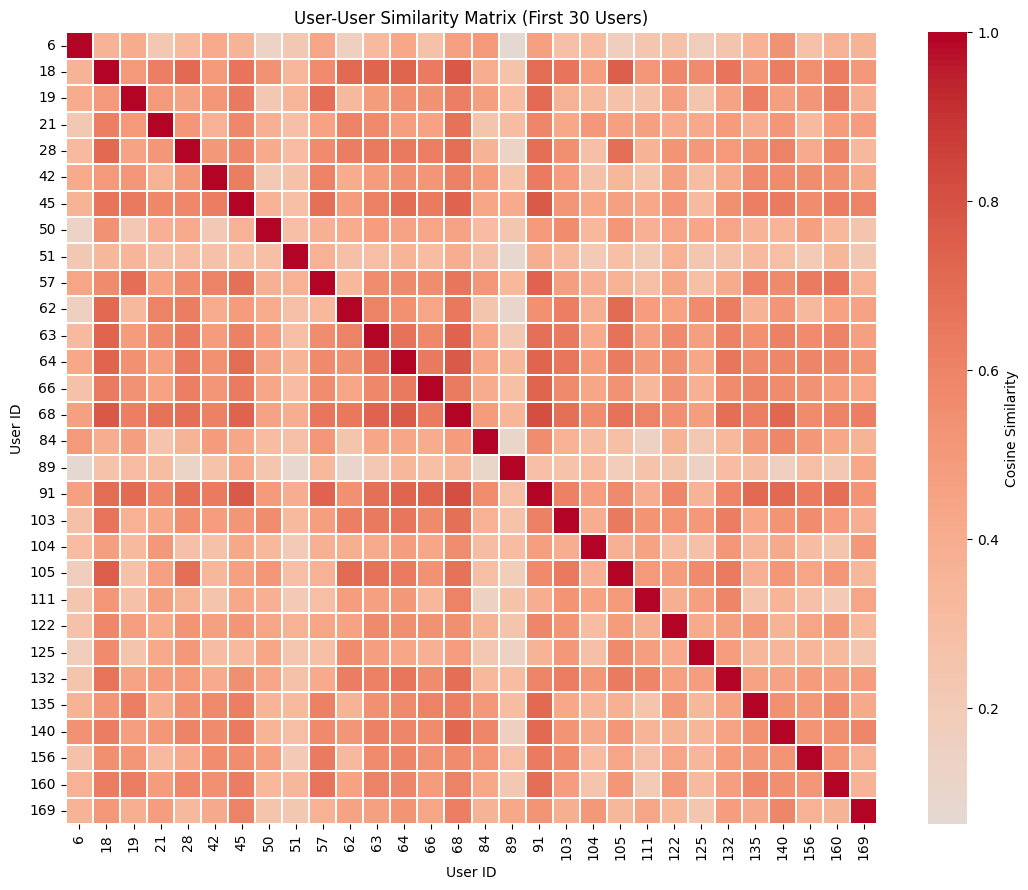

In [46]:
# User similarity matrix heatmap
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(user_sim_df.iloc[:30, :30],
            cmap='coolwarm', center=0, linewidths=0.2, linecolor='white',
            cbar_kws={'label': 'Cosine Similarity'}, ax=ax)
ax.set_title('User-User Similarity Matrix (First 30 Users)')
ax.set_xlabel('User ID')
ax.set_ylabel('User ID')
plt.tight_layout()
plt.savefig('s1_user_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


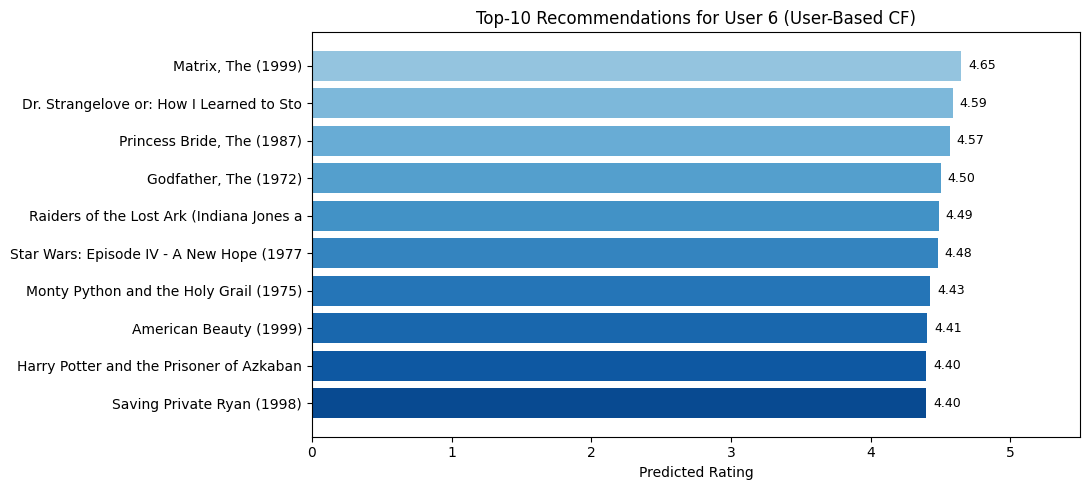

In [47]:
# Top recommended movies bar chart
fig, ax = plt.subplots(figsize=(11, 5))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(recs_s1)))
bars = ax.barh(recs_s1['title'].str[:40], recs_s1['Predicted Rating'], color=colors)
ax.set_xlabel('Predicted Rating')
ax.set_title(f'Top-10 Recommendations for User {SAMPLE_USER} (User-Based CF)')
ax.invert_yaxis()
ax.set_xlim(0, 5.5)
for bar, val in zip(bars, recs_s1['Predicted Rating']):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('s1_top_recommendations.png', dpi=150, bbox_inches='tight')
plt.show()


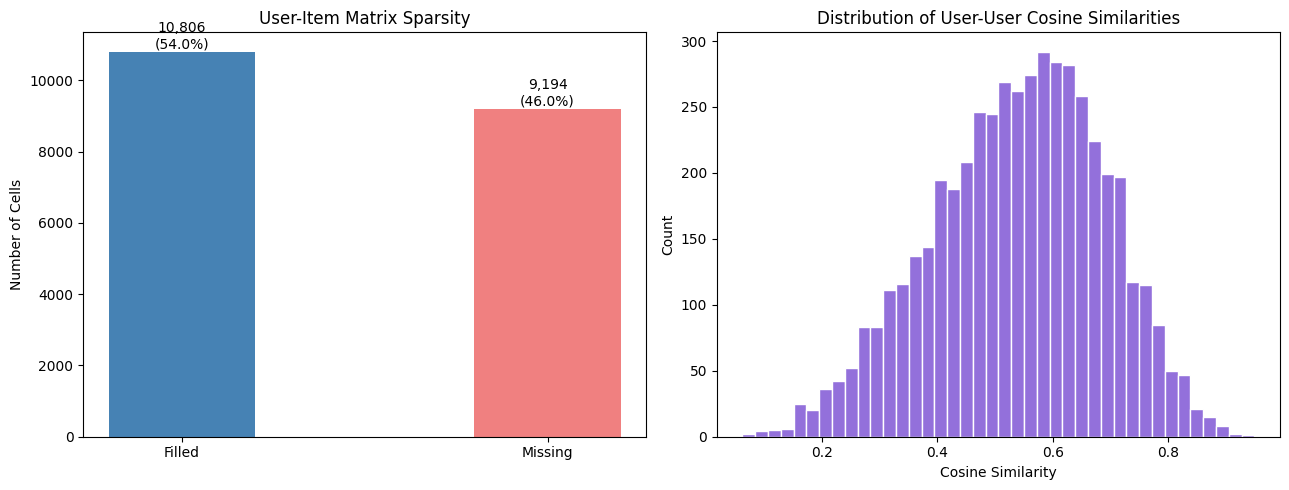

In [48]:
# Sparsity analysis plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

categories = ['Filled', 'Missing']
values     = [filled, total_cells - filled]
axes[0].bar(categories, values, color=['steelblue', 'lightcoral'], width=0.4)
axes[0].set_title('User-Item Matrix Sparsity')
axes[0].set_ylabel('Number of Cells')
for i, v in enumerate(values):
    axes[0].text(i, v + 100, f'{v:,}\n({v/total_cells:.1%})', ha='center', fontsize=10)

all_sim_vals = user_sim_array[np.triu_indices_from(user_sim_array, k=1)]
axes[1].hist(all_sim_vals, bins=40, color='mediumpurple', edgecolor='white')
axes[1].set_title('Distribution of User-User Cosine Similarities')
axes[1].set_xlabel('Cosine Similarity')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('s1_sparsity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Scenario 2 – Item-Based Collaborative Filtering

### 1. Load Dataset

In [49]:
# dataset already loaded above
print(f"ratings : {ratings.shape}")
print(f"movies  : {movies.shape}")
print("Using same subset: top 100 users x 200 movies")


ratings : (100836, 5)
movies  : (9742, 3)
Using same subset: top 100 users x 200 movies


### 2. Create Item-User Matrix

In [50]:
# transpose the user-item matrix
item_user_matrix = user_item_matrix.T
item_user_filled = item_user_matrix.fillna(0)

print(f"Item-User Matrix shape : {item_user_matrix.shape}")
print(f"  Rows (movies) : {item_user_matrix.shape[0]}")
print(f"  Cols (users)  : {item_user_matrix.shape[1]}")


Item-User Matrix shape : (200, 100)
  Rows (movies) : 200
  Cols (users)  : 100


### 3. Compute Item Similarity

In [51]:
# cosine similarity
item_cos_array = cosine_similarity(item_user_filled)
item_cos_df    = pd.DataFrame(item_cos_array,
                              index=item_user_filled.index,
                              columns=item_user_filled.index)

# pearson correlation
item_pearson_df = item_user_filled.T.corr(method='pearson')

print(f"Item Cosine Similarity shape  : {item_cos_df.shape}")
print(f"Item Pearson Correlation shape: {item_pearson_df.shape}")

print("\nCosine similarity sample (4x4):")
display(item_cos_df.iloc[:4, :4].round(3))

print("\nPearson correlation sample (4x4):")
display(item_pearson_df.iloc[:4, :4].round(3))


Item Cosine Similarity shape  : (200, 200)
Item Pearson Correlation shape: (200, 200)

Cosine similarity sample (4x4):


movieId,1,2,6,10
movieId,,,,
1,1.000,0.616,0.528,0.584
2,0.616,1.000,0.469,0.536
6,0.528,0.469,1.000,0.567
10,0.584,0.536,0.567,1.000



Pearson correlation sample (4x4):


movieId,1,2,6,10
movieId,,,,
1,1.000,0.065,-0.038,0.083
2,0.065,1.000,0.032,0.145
6,-0.038,0.032,1.000,0.253
10,0.083,0.145,0.253,1.000


### 4. Identify Top Similar Items

In [52]:
def get_similar_items(movie_id, sim_df, movies_df, n=10):
    if movie_id not in sim_df.index:
        return pd.DataFrame()
    scores = sim_df[movie_id].drop(index=movie_id).sort_values(ascending=False).head(n)
    result = scores.reset_index()
    result.columns = ['movieId', 'Similarity']
    return result.merge(movies_df[['movieId','title','genres']], on='movieId', how='left')

SAMPLE_MOVIE = item_user_filled.index[0]
title_str    = movies[movies['movieId'] == SAMPLE_MOVIE]['title'].values[0]
similar_items = get_similar_items(SAMPLE_MOVIE, item_cos_df, movies)

print(f"Top-10 movies similar to '{title_str}':")
display(similar_items[['title','genres','Similarity']])


Top-10 movies similar to 'Toy Story (1995)':


,title,genres,Similarity
0,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,0.849236
1,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,0.830779
2,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,0.829675
3,Raiders of the Lost Ark (Indiana Jones and the...,Action|Adventure,0.828330
4,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi,0.827613
5,Back to the Future (1985),Adventure|Comedy|Sci-Fi,0.821832
6,"Matrix, The (1999)",Action|Sci-Fi|Thriller,0.815542
7,Shrek (2001),Adventure|Animation|Children|Comedy|Fantasy|Ro...,0.808558
8,Groundhog Day (1993),Comedy|Fantasy|Romance,0.800323
9,Indiana Jones and the Last Crusade (1989),Action|Adventure,0.797840


### 5. Recommend Items Based on User History

In [53]:
def recommend_item_based(target_user, item_user_mat, item_sim_df, movies_df, n=10):
    if target_user not in item_user_mat.columns:
        return pd.DataFrame()
    user_col       = item_user_mat[target_user]
    rated_ids      = user_col[user_col > 0].index.tolist()
    unrated_ids    = user_col[user_col == 0].index.tolist()
    scores = {}
    for unrated_mid in unrated_ids:
        if unrated_mid not in item_sim_df.index:
            continue
        numer, denom = 0.0, 0.0
        for rated_mid in rated_ids:
            if rated_mid not in item_sim_df.index:
                continue
            sim = item_sim_df.loc[unrated_mid, rated_mid]
            numer += sim * user_col[rated_mid]
            denom += abs(sim)
        if denom > 0:
            scores[unrated_mid] = numer / denom
    rec = pd.Series(scores).sort_values(ascending=False).head(n).reset_index()
    rec.columns = ['movieId', 'Predicted Rating']
    return rec.merge(movies_df[['movieId','title','genres']], on='movieId', how='left')

recs_s2 = recommend_item_based(SAMPLE_USER, item_user_filled, item_cos_df, movies)
print(f"Top-10 recommendations for User {SAMPLE_USER} (Item-Based CF):")
display(recs_s2[['title','genres','Predicted Rating']])


Top-10 recommendations for User 6 (Item-Based CF):


,title,genres,Predicted Rating
0,Titanic (1997),Drama|Romance,3.842079
1,Ice Age (2002),Adventure|Animation|Children|Comedy,3.832894
2,Cast Away (2000),Drama,3.832777
3,Harry Potter and the Chamber of Secrets (2002),Adventure|Fantasy,3.830831
4,Finding Nemo (2003),Adventure|Animation|Children|Comedy,3.830818
5,"Rock, The (1996)",Action|Adventure|Thriller,3.830620
6,"Incredibles, The (2004)",Action|Adventure|Animation|Children|Comedy,3.829809
7,Harry Potter and the Prisoner of Azkaban (2004),Adventure|Fantasy|IMAX,3.826271
8,Shrek (2001),Adventure|Animation|Children|Comedy|Fantasy|Ro...,3.825848
9,Top Gun (1986),Action|Romance,3.824848


### 6. Compare Item-Based vs User-Based Recommendations

In [54]:
print(f"Recommendations for User {SAMPLE_USER}")
print(f"{'USER-BASED CF':<35} | {'ITEM-BASED CF'}")
print("-" * 72)

ub_titles = recs_s1['title'].str[:33].tolist() if not recs_s1.empty else []
ib_titles = recs_s2['title'].str[:33].tolist() if not recs_s2.empty else []

for i in range(max(len(ub_titles), len(ib_titles))):
    ub = ub_titles[i] if i < len(ub_titles) else ''
    ib = ib_titles[i] if i < len(ib_titles) else ''
    print(f"{ub:<35} | {ib}")

overlap = set(recs_s1['movieId']) & set(recs_s2['movieId'])
print(f"\nCommon recommendations: {len(overlap)}")
if overlap:
    for t in movies[movies['movieId'].isin(overlap)]['title'].tolist():
        print(f"  - {t}")


Recommendations for User 6
USER-BASED CF                       | ITEM-BASED CF
------------------------------------------------------------------------
Matrix, The (1999)                  | Titanic (1997)
Dr. Strangelove or: How I Learned   | Ice Age (2002)
Princess Bride, The (1987)          | Cast Away (2000)
Godfather, The (1972)               | Harry Potter and the Chamber of S
Raiders of the Lost Ark (Indiana    | Finding Nemo (2003)
Star Wars: Episode IV - A New Hop   | Rock, The (1996)
Monty Python and the Holy Grail (   | Incredibles, The (2004)
American Beauty (1999)              | Harry Potter and the Prisoner of 
Harry Potter and the Prisoner of    | Shrek (2001)
Saving Private Ryan (1998)          | Top Gun (1986)

Common recommendations: 1
  - Harry Potter and the Prisoner of Azkaban (2004)


### 7. Evaluate – RMSE and Precision@K

In [55]:
# build item-user train matrix (same split from Scenario 1)
train_ib_mat = train_data.pivot_table(index='movieId', columns='userId', values='rating').fillna(0)
train_ib_sim = cosine_similarity(train_ib_mat)
train_ib_sim_df = pd.DataFrame(train_ib_sim, index=train_ib_mat.index, columns=train_ib_mat.index)

y_true_ib, y_pred_ib = [], []

for _, row in test_data.iterrows():
    uid, mid = row['userId'], row['movieId']
    if uid not in train_ib_mat.columns or mid not in train_ib_mat.index:
        continue
    user_col = train_ib_mat[uid]
    rated    = user_col[user_col > 0]
    numer, denom = 0.0, 0.0
    for r_mid, r_val in rated.items():
        if r_mid not in train_ib_sim_df.index:
            continue
        sim = train_ib_sim_df.loc[mid, r_mid]
        numer += sim * r_val
        denom += abs(sim)
    if denom > 0:
        y_true_ib.append(row['rating'])
        y_pred_ib.append(numer / denom)

rmse_s2 = np.sqrt(mean_squared_error(y_true_ib, y_pred_ib))
mae_s2  = mean_absolute_error(y_true_ib, y_pred_ib)

print(f"Predictions : {len(y_pred_ib)}")
print(f"RMSE        : {rmse_s2:.4f}")
print(f"MAE         : {mae_s2:.4f}")


Predictions : 2162
RMSE        : 0.8549
MAE         : 0.6664


In [56]:
# Precision@K

def recommend_item_based_from_train(target_user, train_mat, item_sim_df, movies_df, n=10):
    if target_user not in train_mat.columns:
        return pd.DataFrame()
    user_col    = train_mat[target_user]
    rated_ids   = user_col[user_col > 0].index.tolist()
    unrated_ids = user_col[user_col == 0].index.tolist()
    scores = {}
    for unrated_mid in unrated_ids:
        if unrated_mid not in item_sim_df.index:
            continue
        numer, denom = 0.0, 0.0
        for rated_mid in rated_ids:
            if rated_mid not in item_sim_df.index:
                continue
            sim = item_sim_df.loc[unrated_mid, rated_mid]
            numer += sim * user_col[rated_mid]
            denom += abs(sim)
        if denom > 0:
            scores[unrated_mid] = numer / denom
    rec = pd.Series(scores).sort_values(ascending=False).head(n).reset_index()
    rec.columns = ['movieId', 'Predicted Rating']
    return rec.merge(movies_df[['movieId','title','genres']], on='movieId', how='left')

def precision_at_k(recs, ground_truth, k=5, threshold=3.5):
    if recs.empty:
        return 0.0
    top_k    = recs.head(k)['movieId'].tolist()
    relevant = [m for m in top_k if m in ground_truth and ground_truth[m] >= threshold]
    return len(relevant) / k

test_users = test_data['userId'].unique()
precisions = []

for uid in test_users[:30]:
    if uid not in train_ib_mat.columns:
        continue
    recs_uid = recommend_item_based_from_train(uid, train_ib_mat, train_ib_sim_df, movies, n=10)
    if recs_uid.empty:
        continue
    gt = test_data[test_data['userId'] == uid].set_index('movieId')['rating'].to_dict()
    if not gt:
        continue
    precisions.append(precision_at_k(recs_uid, gt, k=5))

mean_p5 = np.mean(precisions) if precisions else 0.0

print(f"Users evaluated  : {len(precisions)}")
print(f"Mean Precision@5 : {mean_p5:.4f} ({mean_p5:.2%})")


Users evaluated  : 30
Mean Precision@5 : 0.3000 (30.00%)


### Visualizations – Scenario 2

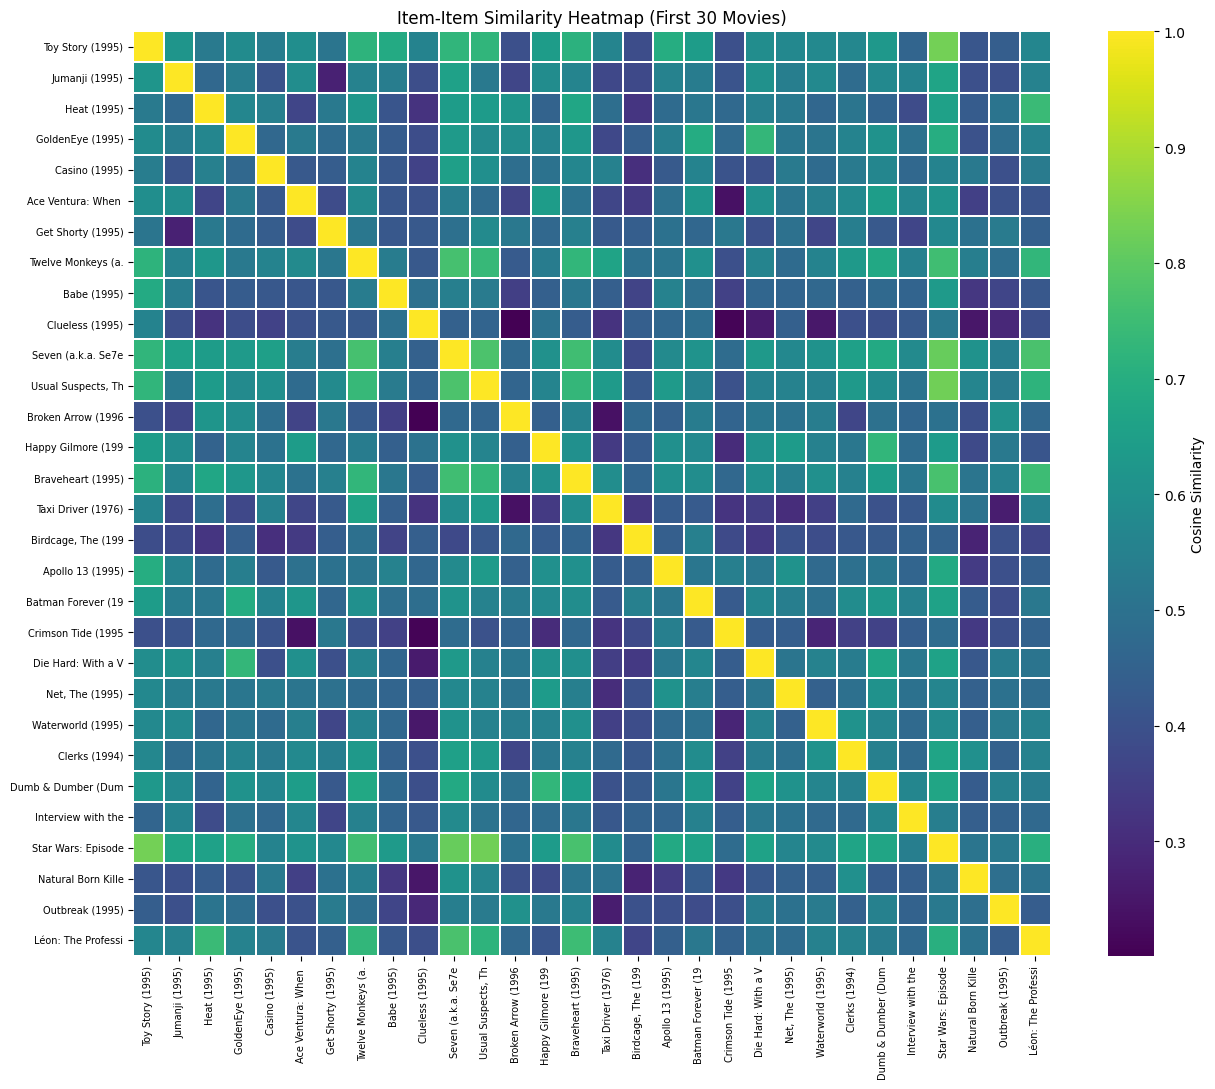

In [57]:
# Item similarity heatmap with movie title labels
ids    = item_cos_df.index[:30].tolist()
labels = [movies[movies['movieId']==m]['title'].values[0][:18]
          if len(movies[movies['movieId']==m]) > 0 else str(m) for m in ids]

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(item_cos_df.iloc[:30, :30].values,
            cmap='viridis', linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Cosine Similarity'},
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title('Item-Item Similarity Heatmap (First 30 Movies)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig('s2_item_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


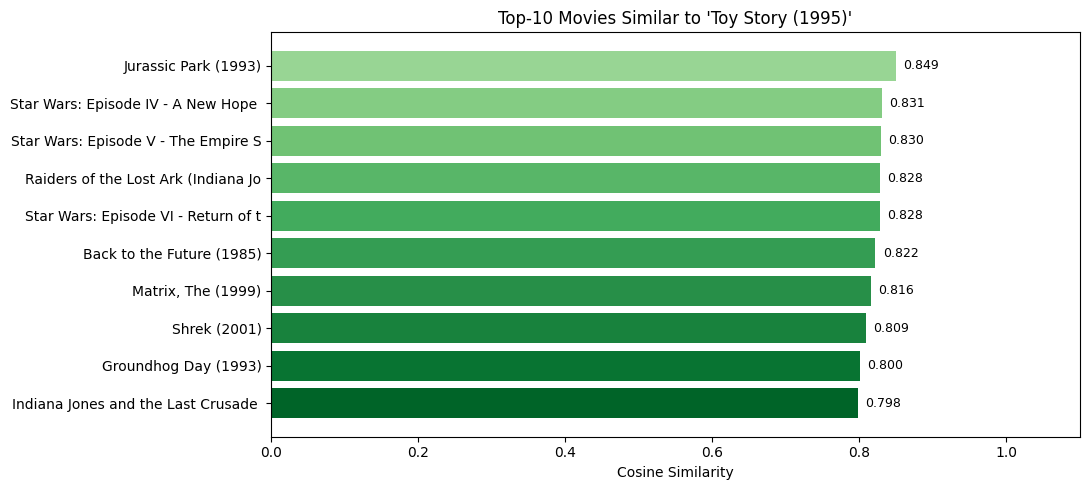

In [58]:
# Top similar items bar chart
fig, ax = plt.subplots(figsize=(11, 5))
colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(similar_items)))
bars   = ax.barh(similar_items['title'].str[:35], similar_items['Similarity'], color=colors)
ax.set_xlabel('Cosine Similarity')
ax.set_title(f"Top-10 Movies Similar to '{title_str[:35]}'")
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
for bar, val in zip(bars, similar_items['Similarity']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('s2_top_similar_items.png', dpi=150, bbox_inches='tight')
plt.show()


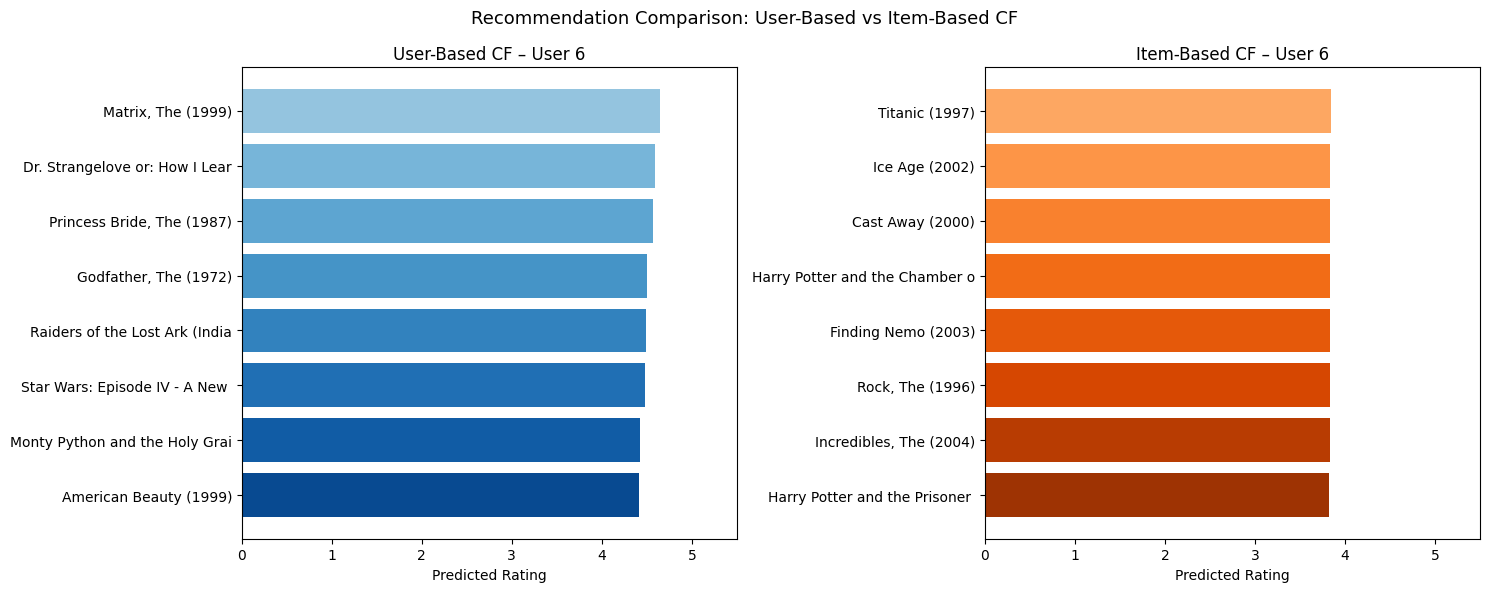

In [59]:
# Recommendation comparison: UB vs IB side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ub_plot = recs_s1.head(8)
axes[0].barh(ub_plot['title'].str[:30], ub_plot['Predicted Rating'],
             color=plt.cm.Blues(np.linspace(0.4, 0.9, len(ub_plot))))
axes[0].set_title(f'User-Based CF – User {SAMPLE_USER}')
axes[0].set_xlabel('Predicted Rating')
axes[0].invert_yaxis()
axes[0].set_xlim(0, 5.5)

ib_plot = recs_s2.head(8)
axes[1].barh(ib_plot['title'].str[:30], ib_plot['Predicted Rating'],
             color=plt.cm.Oranges(np.linspace(0.4, 0.9, len(ib_plot))))
axes[1].set_title(f'Item-Based CF – User {SAMPLE_USER}')
axes[1].set_xlabel('Predicted Rating')
axes[1].invert_yaxis()
axes[1].set_xlim(0, 5.5)

plt.suptitle('Recommendation Comparison: User-Based vs Item-Based CF', fontsize=13)
plt.tight_layout()
plt.savefig('s2_recommendation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


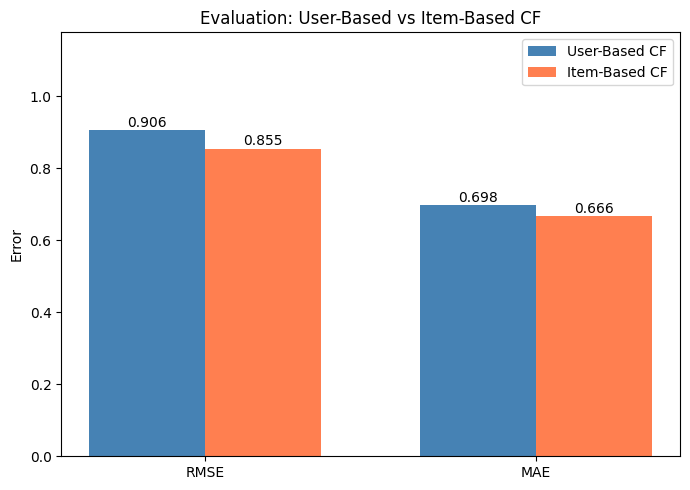

In [60]:
# RMSE and MAE comparison bar chart
fig, ax = plt.subplots(figsize=(7, 5))
x     = np.arange(2)
width = 0.35
b1 = ax.bar(x - width/2, [rmse_s1, mae_s1], width, label='User-Based CF', color='steelblue')
b2 = ax.bar(x + width/2, [rmse_s2, mae_s2], width, label='Item-Based CF',  color='coral')
ax.set_xticks(x)
ax.set_xticklabels(['RMSE', 'MAE'])
ax.set_ylabel('Error')
ax.set_title('Evaluation: User-Based vs Item-Based CF')
ax.legend()
ax.set_ylim(0, max(rmse_s1, mae_s1, rmse_s2, mae_s2) * 1.3)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('s2_rmse_mae_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [63]:
print("=" * 50)
print("   EXPERIMENT 9 – RECOMMENDATION SYSTEMS")
print("=" * 50)
print(f"Roll No.        : 24BAD002")
print(f"Dataset         : MovieLens (ml-latest-small)")
print(f"Total Ratings   : {len(ratings):,}")
print(f"Total Users     : {ratings['userId'].nunique()}")
print(f"Total Movies    : {ratings['movieId'].nunique()}")
print(f"Matrix Sparsity : {sparsity:.2%}")
print()
print("Scenario 1 – User-Based CF")
print(f"  RMSE : {rmse_s1:.4f}")
print(f"  MAE  : {mae_s1:.4f}")
print()
print("Scenario 2 – Item-Based CF")
print(f"  RMSE          : {rmse_s2:.4f}")
print(f"  MAE           : {mae_s2:.4f}")
print(f"  Precision@5   : {mean_p5:.4f} ({mean_p5:.2%})")
print("Better RMSE:", "User-Based" if rmse_s1 < rmse_s2 else "Item-Based")
print("=" * 50)


   EXPERIMENT 9 – RECOMMENDATION SYSTEMS
Roll No.        : 24BAD002
Dataset         : MovieLens (ml-latest-small)
Total Ratings   : 100,836
Total Users     : 610
Total Movies    : 9724
Matrix Sparsity : 45.97%

Scenario 1 – User-Based CF
  RMSE : 0.9061
  MAE  : 0.6975

Scenario 2 – Item-Based CF
  RMSE          : 0.8549
  MAE           : 0.6664
  Precision@5   : 0.3000 (30.00%)
Better RMSE: Item-Based
